MSE: 4085.025480871632
R2 Score: 0.2289715971205667


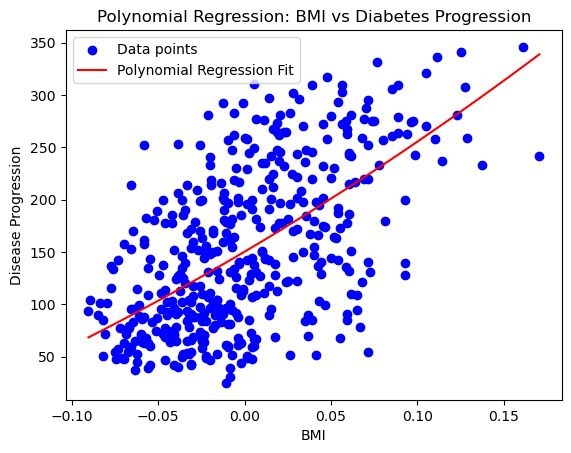

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

# Load dataset
diabetes = load_diabetes()
X = diabetes.data[:, 2].reshape(-1,1)  # BMI feature
y = diabetes.target  # Disease progression

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial features (degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Fit model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict
y_pred = model.predict(X_test_poly)

# Evaluate
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot
plt.scatter(X, y, color='blue', label='Data points')
X_plot = np.linspace(min(X), max(X), 100).reshape(-1,1)
y_plot = model.predict(poly.transform(X_plot))
plt.plot(X_plot, y_plot, color='red', label='Polynomial Regression Fit')
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Polynomial Regression: BMI vs Diabetes Progression")
plt.legend()
plt.show()
